In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
def parse_line(line):
    pairs = line.strip().split(',')
    data = {}
    for pair in pairs:
        if ':' in pair:
            key, value = pair.split(':', 1)
            data[key.strip()] = float(value.strip())
    return data

In [3]:
# Read the file and parse each line
file_path = "./logs/level_5_small_counters.trec"  # Replace with your file path
data = []

with open(file_path, 'r') as file:
    for line in file:
        if line.strip():  # Skip empty lines
            parsed_data = parse_line(line)
            data.append(parsed_data)

# Create DataFrame
df = pd.DataFrame(data)

# df = df.set_index("qid")
# Display the DataFrame
df.iloc[[-1]]


,qid,termcnt,wcnt,non_es,f1,f2,f3,p1,p2,p3,p4,p5,p6,p7,br1,br2
6979,1048565.0,4.0,148616.0,1.0,481159.0,113305.0,31664.0,152198.0,178376.0,388.0,37228.0,316.0,9191.0,1.0,81641.0,28037.0


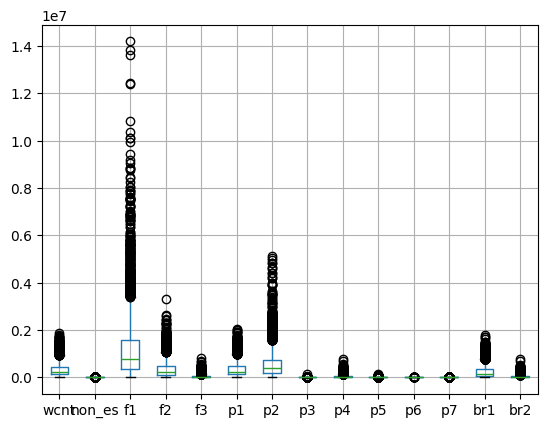

In [4]:
df_cols = df.columns.to_list()

df.boxplot(column=df_cols[2:])
plt.show()

In [5]:
from scipy import stats


In [6]:
df_filtered = df[(np.abs(stats.zscore(df["f1"])) < 3)]

In [7]:
df_filtered.isnull().values.any()


np.False_

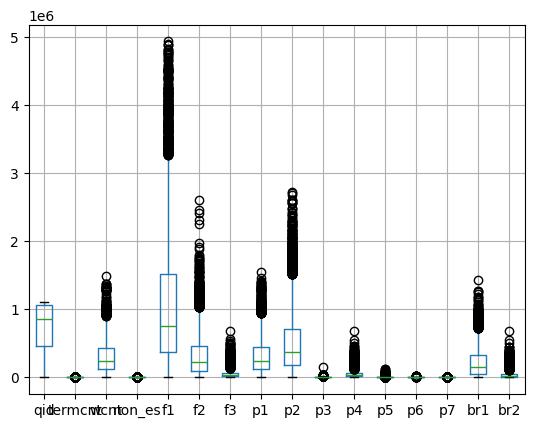

In [8]:
df_cols = df.columns.to_list()


df_filtered.boxplot()
plt.show()

In [9]:
# Read the file and parse each line
file_path = "./logs/level_5_small_timings.trec"  # Replace with your file path
data = []

with open(file_path, 'r') as file:
    for line in file:
        if line.strip():  # Skip empty lines
            parsed_data = parse_line(line)
            data.append(parsed_data)

# Create DataFrame
dft = pd.DataFrame(data)

# dft = dft.set_index("qid")
# Display the DataFrame
dft.iloc[[-1]]

,qid,termcnt,alg_prep_ms,alg_while_ms,alg_total_ms
6979,1048565.0,4.0,0.0,3.0,3.0


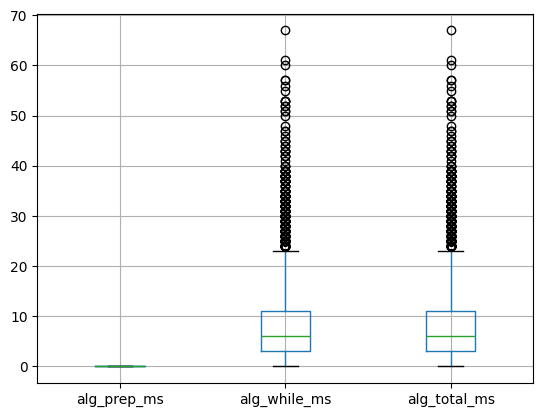

In [10]:
dft.boxplot(column=dft.columns.to_list()[2:])
plt.show()

In [11]:
df["time"] = dft["alg_total_ms"]

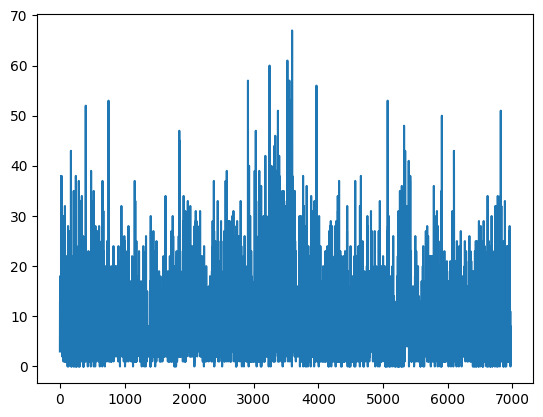

In [12]:
dft["alg_total_ms"].plot()
plt.show()

In [13]:
df.head()

,qid,termcnt,wcnt,non_es,f1,f2,f3,p1,p2,p3,p4,p5,p6,p7,br1,br2,time
0,1048585.0,4.0,44151.0,2.0,109898.0,58716.0,26207.0,44301.0,83054.0,950.0,27407.0,90.0,6683.0,2.0,12110.0,20724.0,3.0
1,2.0,4.0,264389.0,1.0,827584.0,229972.0,13878.0,269225.0,308758.0,12544.0,19204.0,810.0,8160.0,1.0,216094.0,11044.0,12.0
2,524332.0,5.0,277941.0,1.0,1130628.0,259077.0,10588.0,285618.0,588671.0,4503.0,15393.0,1620.0,6998.0,1.0,248489.0,8395.0,13.0
3,1048642.0,3.0,86698.0,1.0,188168.0,71926.0,12970.0,87645.0,89057.0,9638.0,16705.0,1621.0,7049.0,1.0,58956.0,9656.0,5.0
4,524447.0,7.0,274595.0,3.0,1152432.0,388284.0,52019.0,284693.0,724160.0,9181.0,46452.0,4785.0,7422.0,3.0,227831.0,39030.0,18.0


In [14]:
!pip install seaborn

You should consider upgrading via the '/Users/po_oya/research/codes/effmetrics/pisa/analysis/effenv/bin/python3.9 -m pip install --upgrade pip' command.


In [15]:


import seaborn as sns


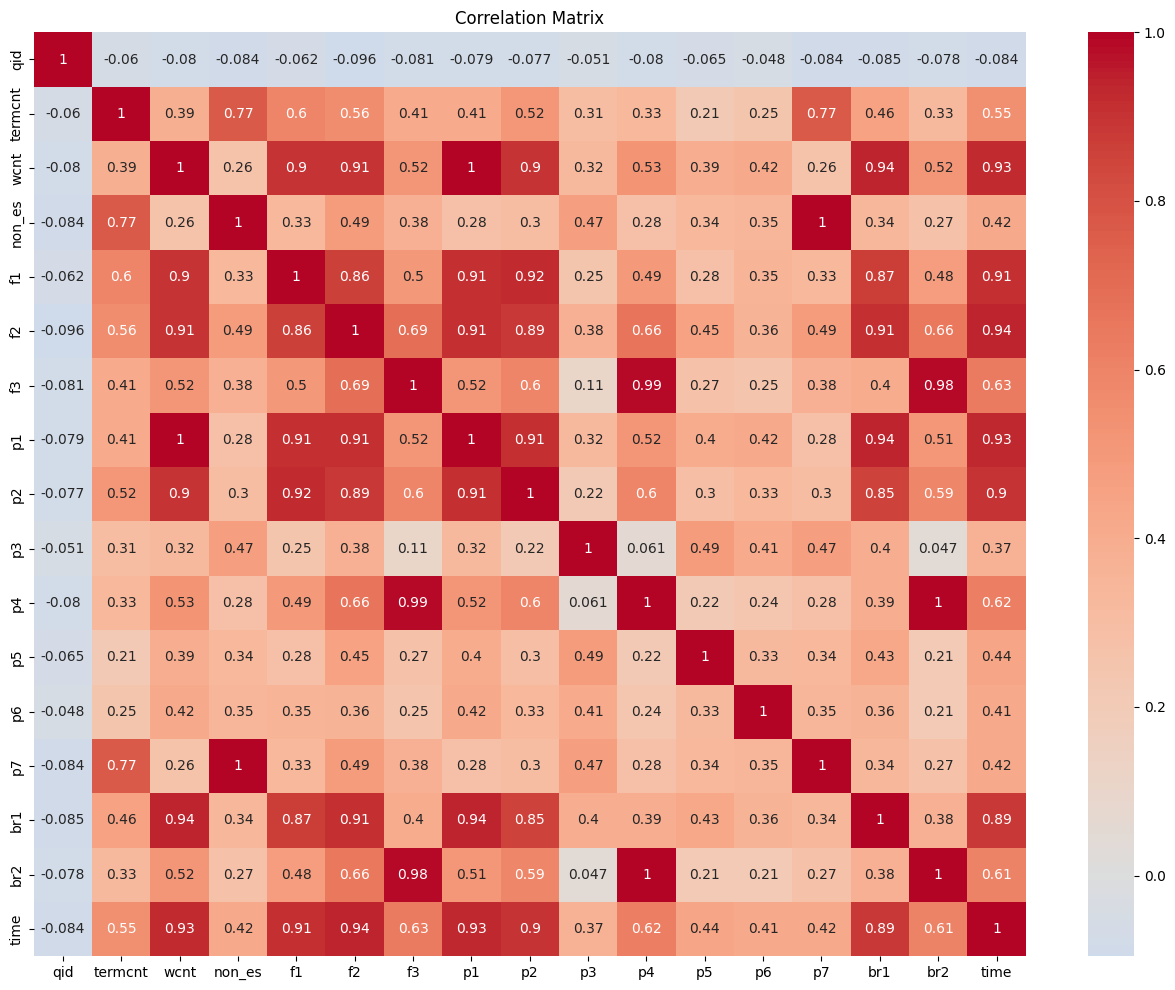

In [16]:
# Standardize the data (z-score normalization)
df_standardized = (df - df.mean()) / df.std()

# Calculate the correlation matrix
correlation_matrix = df_standardized.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

/var/folders/lx/9pkjhxms7k3_g28656gglyw00000gn/T/ipykernel_24369/139561228.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette='coolwarm')


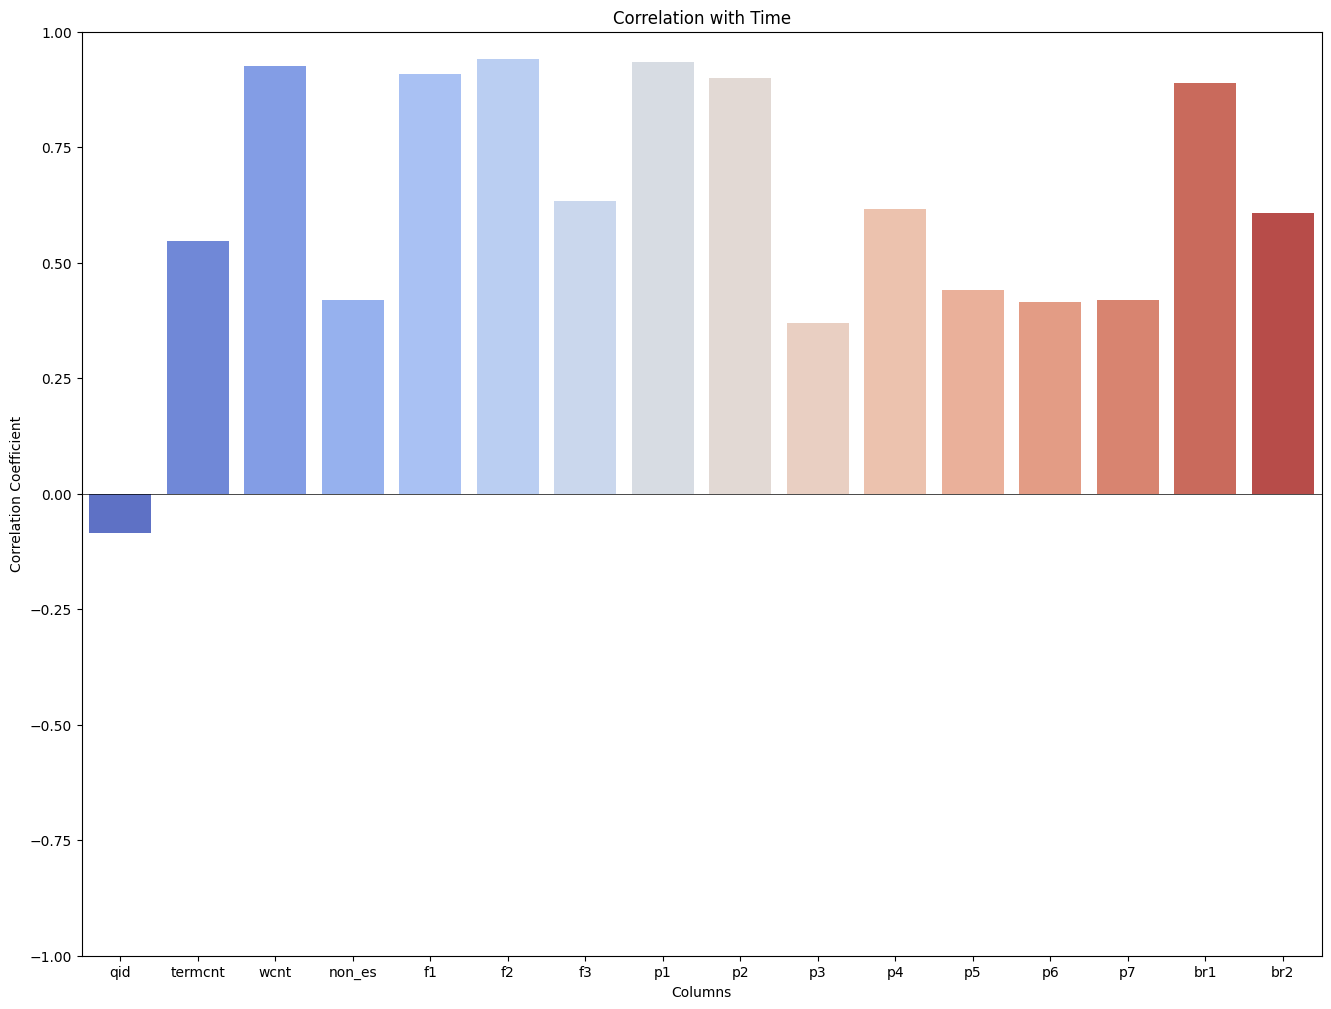

In [17]:
# Standardize the "time" column
time_standardized = (df['time'] - df['time'].mean()) / df['time'].std()

# Standardize the rest of the columns
df_standardized = df.drop(columns=['time'])
df_standardized = (df_standardized - df_standardized.mean()) / df_standardized.std()

# Calculate the correlation between "time" and the rest of the columns
correlations = df_standardized.apply(lambda x: np.corrcoef(time_standardized, x)[0, 1])

# Plot the correlations
plt.figure(figsize=(16, 12))
sns.barplot(x=correlations.index, y=correlations.values, palette='coolwarm')
plt.title('Correlation with Time')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Columns')
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

In [18]:
dcf = df.copy()

In [19]:
!pip install scikit-learn

You should consider upgrading via the '/Users/po_oya/research/codes/effmetrics/pisa/analysis/effenv/bin/python3.9 -m pip install --upgrade pip' command.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Mean Squared Error: 3.7304373096470402
R^2 Score: 0.9339308027492834


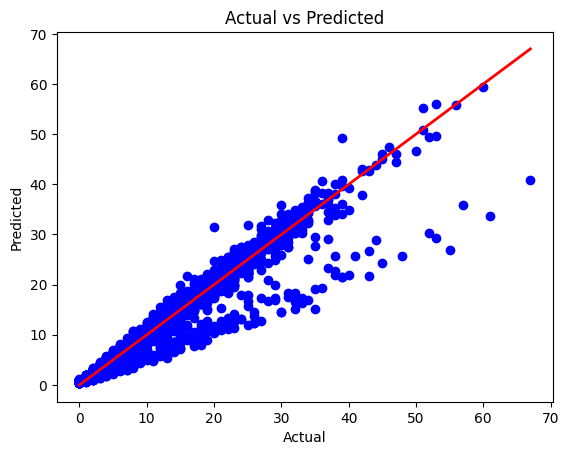

In [21]:
# Define features and target
# X = df.drop(columns=['time', 'qid', 'termcnt', 'wcnt', 'non_es', 'p6', 'p7']) # initial exps

df_time = df['time']
df = (df-df.min())/(df.max()-df.min())
df['time'] = df_time

X = df.drop(columns=['time', 'qid', 'termcnt', 'non_es', 'p6', 'p7', 'p4', 'br1', 'br2', 'p2']) # here I check If a different look at the numbers and choosing different vars can cause a difference
y = df['time']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.95, random_state=42)

# Initialize and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Plotting the results
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [22]:
df.head()

,qid,termcnt,wcnt,non_es,f1,f2,f3,p1,p2,p3,p4,p5,p6,p7,br1,br2,time
0,0.951184,0.166667,0.022727,0.333333,0.007481,0.017734,0.031121,0.020784,0.015772,0.006333,0.032730,0.000697,0.326255,0.333333,0.006704,0.026568,3.0
1,0.000000,0.166667,0.141215,0.166667,0.058089,0.069459,0.016480,0.131087,0.059874,0.083618,0.022303,0.006271,0.422170,0.166667,0.119625,0.014158,12.0
2,0.475627,0.250000,0.148506,0.166667,0.079459,0.078250,0.012573,0.139126,0.114569,0.030017,0.017458,0.012542,0.346711,0.166667,0.137558,0.010762,13.0
3,0.951235,0.083333,0.045617,0.166667,0.013000,0.021724,0.015402,0.042040,0.016945,0.064247,0.019126,0.012550,0.350023,0.166667,0.032637,0.012379,5.0
4,0.475731,0.416667,0.146706,0.500000,0.080996,0.117275,0.061773,0.138673,0.141044,0.061201,0.056939,0.037046,0.374245,0.500000,0.126122,0.050036,18.0


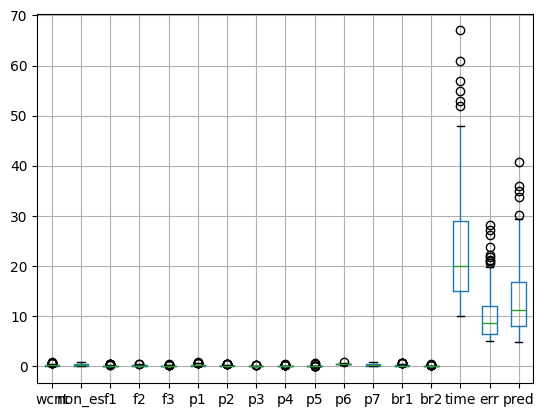

In [23]:
df['err'] = df['time'] - model.predict(X)
df['pred'] = model.predict(X)
df_selected = df[df['err'] > 5]

df_selected_cols = df_selected.columns.to_list()

df_selected.boxplot(column=df_selected_cols[2:])
plt.show()

In [24]:
# Get model coefficients
coefficients = model.coef_
intercept = model.intercept_

# Print model coefficients and intercept
print("Model Coefficients:")
for i, col in enumerate(X.columns):
    print(f"{col}: {coefficients[i]}")
print(f"Intercept: {intercept}")

Model Coefficients:
wcnt: -41.91219015312982
f1: 22.164525796073974
f2: 18.553453603170517
f3: 12.158514505680252
p1: 60.488625811851776
p3: 9.340044652762609
p5: 10.7849796276282
Intercept: 0.38239762152994494


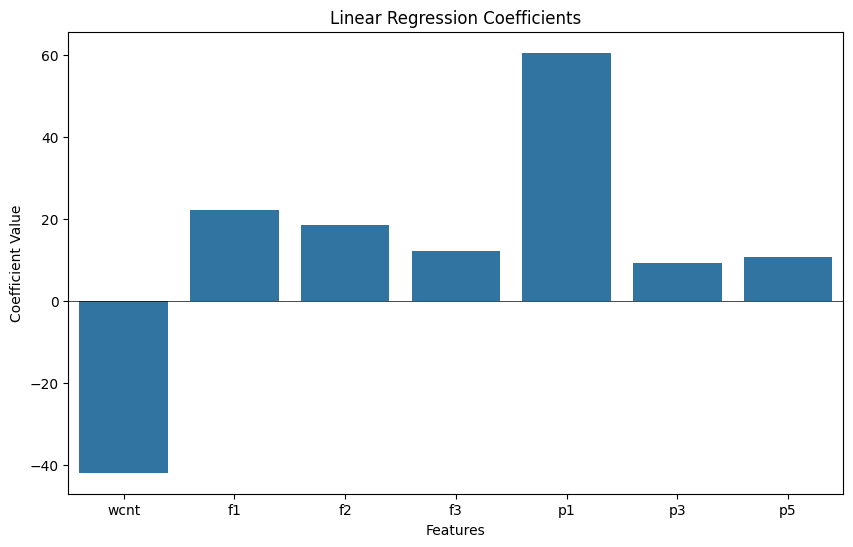

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=coefficients)
plt.title('Linear Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

In [ ]:
scaler = StandardScaler()

scaling_columns = ['f1', 'f2', 'f3', 'p1', 'p2', 'p3', 'p4', 'p5', 'br1', 'br2', 'pred', 'time', 'err']
# scaling_columns = ['err']


df_scaled = pd.DataFrame(scaler.fit_transform(df[scaling_columns]), columns=scaling_columns)
df_scaled.boxplot(column=scaling_columns)
plt.show()

In [38]:
df_scaled = df
scaling_columns = ['f1', 'f2', 'f3', 'p1', 'p3', 'p5']

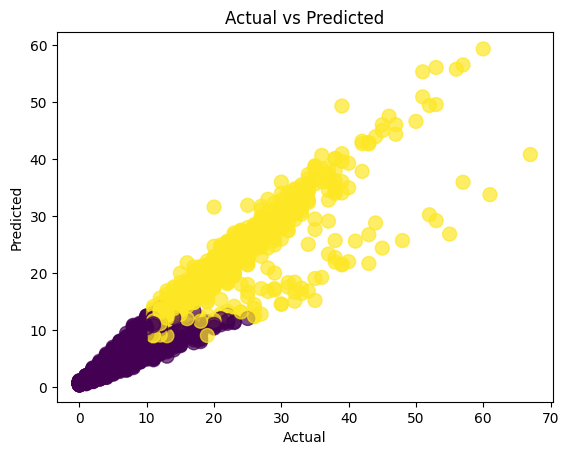

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

kmeans.fit(df_scaled[scaling_columns])

# Get the cluster labels assigned by the algorithm
cluster_labels = kmeans.labels_

df['cluster_kmeans'] = cluster_labels


plt.scatter(df['time'], df['pred'], c=df['cluster_kmeans'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()


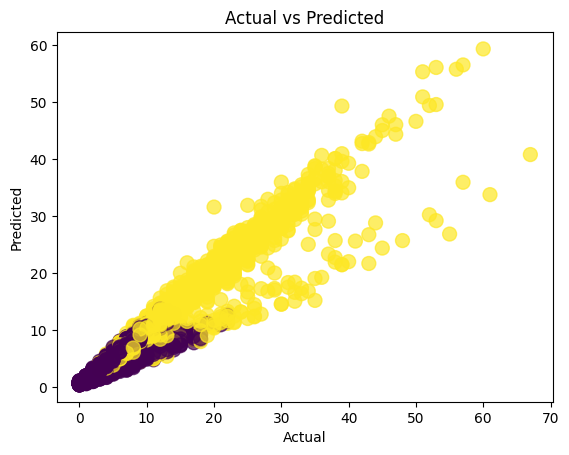

In [40]:
from sklearn.mixture import GaussianMixture

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=2)
gmm_labels = gmm.fit_predict(df_scaled[scaling_columns])

# cluster_labels = kmeans.labels_
df['cluster_gmm'] = gmm_labels

plt.scatter(df['time'], df['pred'], c=df['cluster_gmm'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()


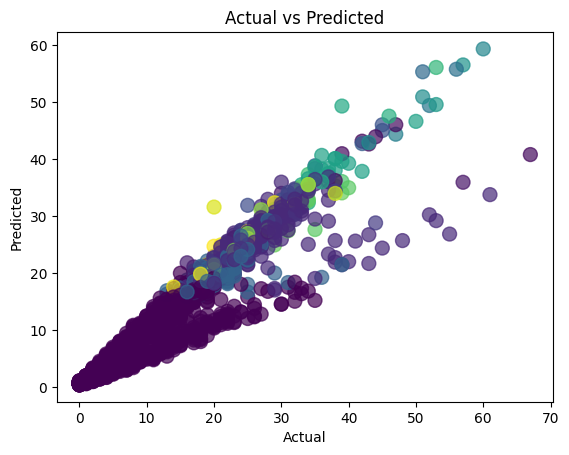

In [41]:
from sklearn.cluster import MeanShift

# Gaussian Mixture Model
msc = MeanShift()
msc_labels = msc.fit_predict(df_scaled[scaling_columns])

# cluster_labels = kmeans.labels_
df['cluster_msc'] = msc_labels

plt.scatter(df['time'], df['pred'], c=df['cluster_msc'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

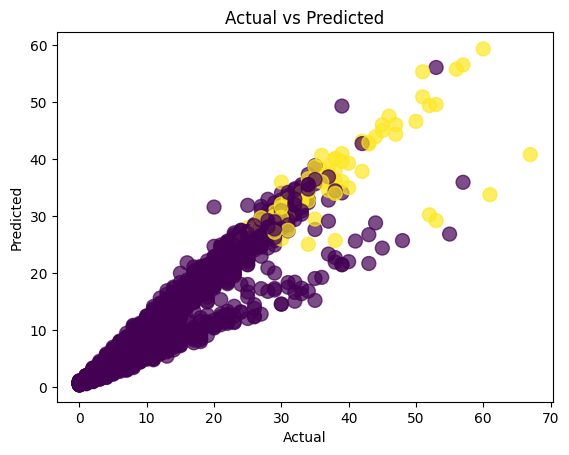

In [42]:

from scipy import stats

df['is_outlier'] = stats.zscore(df['br1'])


# cluster_labels = kmeans.labels_
df['is_outlier'] = df['is_outlier'].apply(lambda x: 1 if abs(x) > 3 else 0)

plt.scatter(df['time'], df['pred'], c=df['is_outlier'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

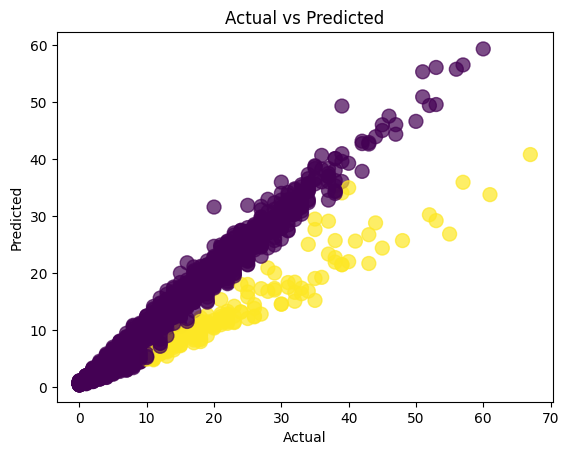

In [43]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

kmeans.fit(df_scaled[['err']])

# Get the cluster labels assigned by the algorithm
cluster_labels = kmeans.labels_

df['cluster_kmeans'] = cluster_labels


plt.scatter(df['time'], df['pred'], c=df['cluster_kmeans'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [46]:
df['mem_read_estimate_naive'] = df['time'] / (df['f1'] + df['p1'] + df['f2'] + df['p3'] + df['wcnt'] + df['f3'] + df['p5'])
df['mem_read_estimate_model'] = df['time'] / (df['f1'] + 3 * df['p1'] + 6 * df['f2'] + 2 * df['p3'] + df['wcnt'] + 6 * df['f3'] + df['p5'])

In [53]:
df['mem_read_estimate_naive'].describe()

count    6979.000000
mean       12.415717
std         3.383159
min         0.000000
25%        11.210690
50%        12.224874
75%        13.216547
max        41.908942
Name: mem_read_estimate_naive, dtype: float64

In [48]:
df['mem_read_estimate_model'].describe()

count    6979.000000
mean        4.560605
std         1.488243
min         0.000000
25%         3.983076
50%         4.378087
75%         4.855078
max        22.794771
Name: mem_read_estimate_model, dtype: float64

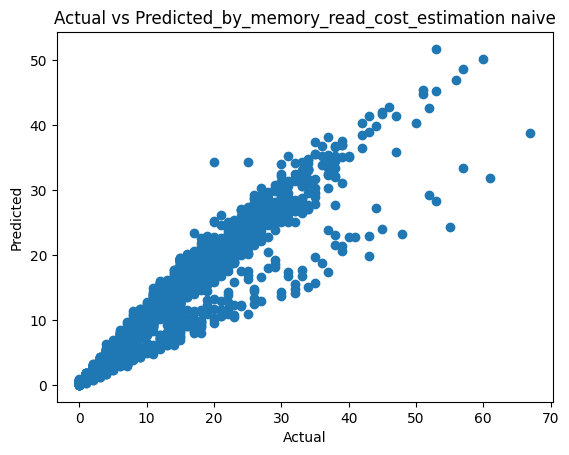

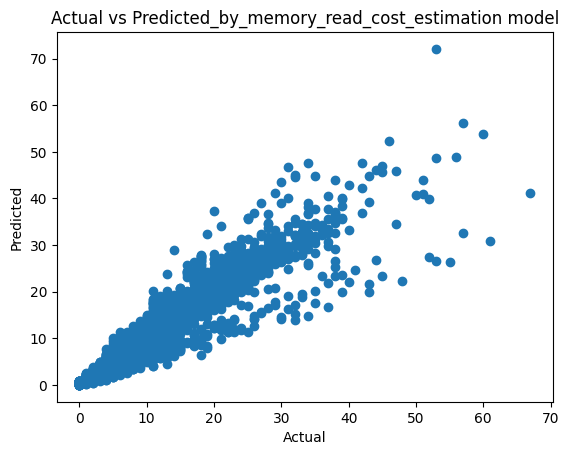

In [62]:
mem_read_estimate_naive_val = df['mem_read_estimate_naive'].describe()['mean']
mem_read_estimate_model_val = df['mem_read_estimate_model'].describe()['mean']

df['time_pred_naive'] = (df['f1'] + df['p1'] + df['f2'] + df['p3'] + df['wcnt'] + df['f3'] + df['p5']) * mem_read_estimate_naive_val
df['time_pred_model'] = (df['f1'] + 3 * df['p1'] + 6 * df['f2'] + 2 * df['p3'] + df['wcnt'] + 6 * df['f3'] + df['p5']) * mem_read_estimate_model_val

plt.scatter(df['time'], df['time_pred_naive'], label='naive')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted_by_memory_read_cost_estimation naive')
plt.show()

plt.scatter(df['time'], df['time_pred_model'], label='model')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted_by_memory_read_cost_estimation model')
plt.show()